In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import analysis_tools as at

PROJECT_ROOT = Path("~/UNSW-PhD/seacofs_eddy_dataset_modular").expanduser()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from seacofs_eddy_dataset.config import load_config

TILT_ROOT = Path("~/UNSW-PhD/seacofs_eddy_tilt_analysis").expanduser()
if str(TILT_ROOT) not in sys.path:
    sys.path.insert(0, str(TILT_ROOT))
import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid=tilt.load_grid(paths.grid,paths.z_r)


In [2]:
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
df_eddies.head()

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000032,...,29.449052,7.225911,1.973172,20.004291,26,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000041,...,29.449052,7.225911,1.859668,18.906549,26,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000035,...,32.090160,7.712683,1.745185,20.859920,26,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,34.827275,8.275696,1.433213,18.674495,26,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,19.823350,87.507772,D1
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000026,...,37.564389,8.838709,1.140614,21.564028,26,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,15.055658,105.302388,D1


In [3]:
df_vert = tilt.load_vert(paths)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


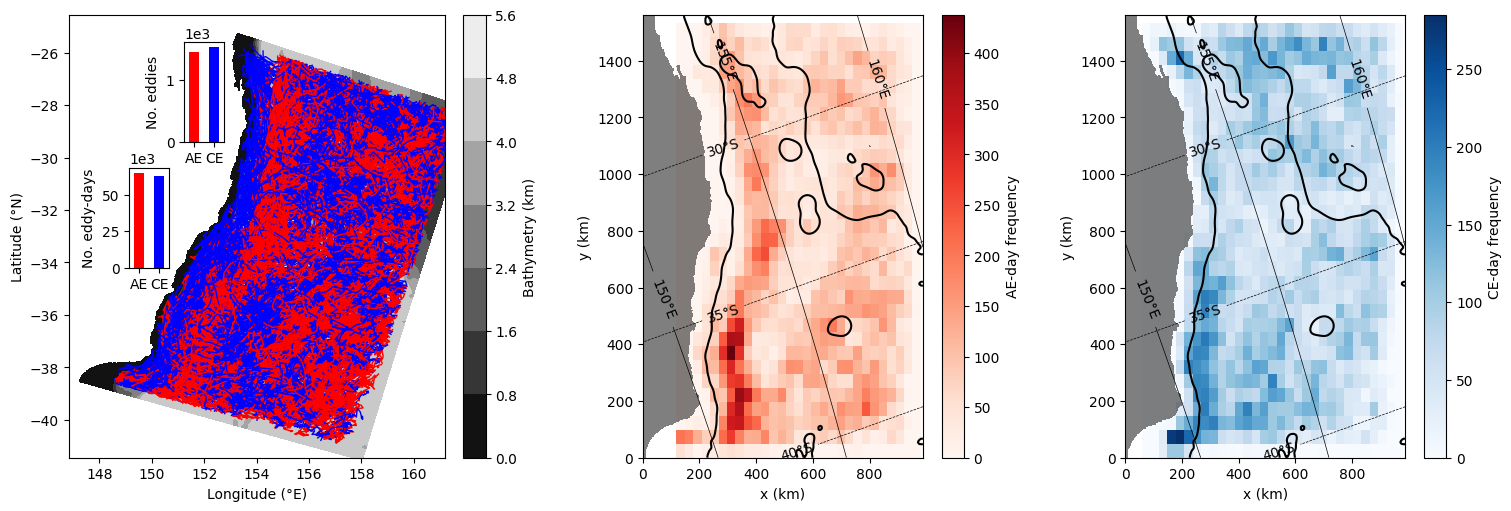

In [4]:
fig, axs = at.distribution_plot(df_eddies.copy(), grid)

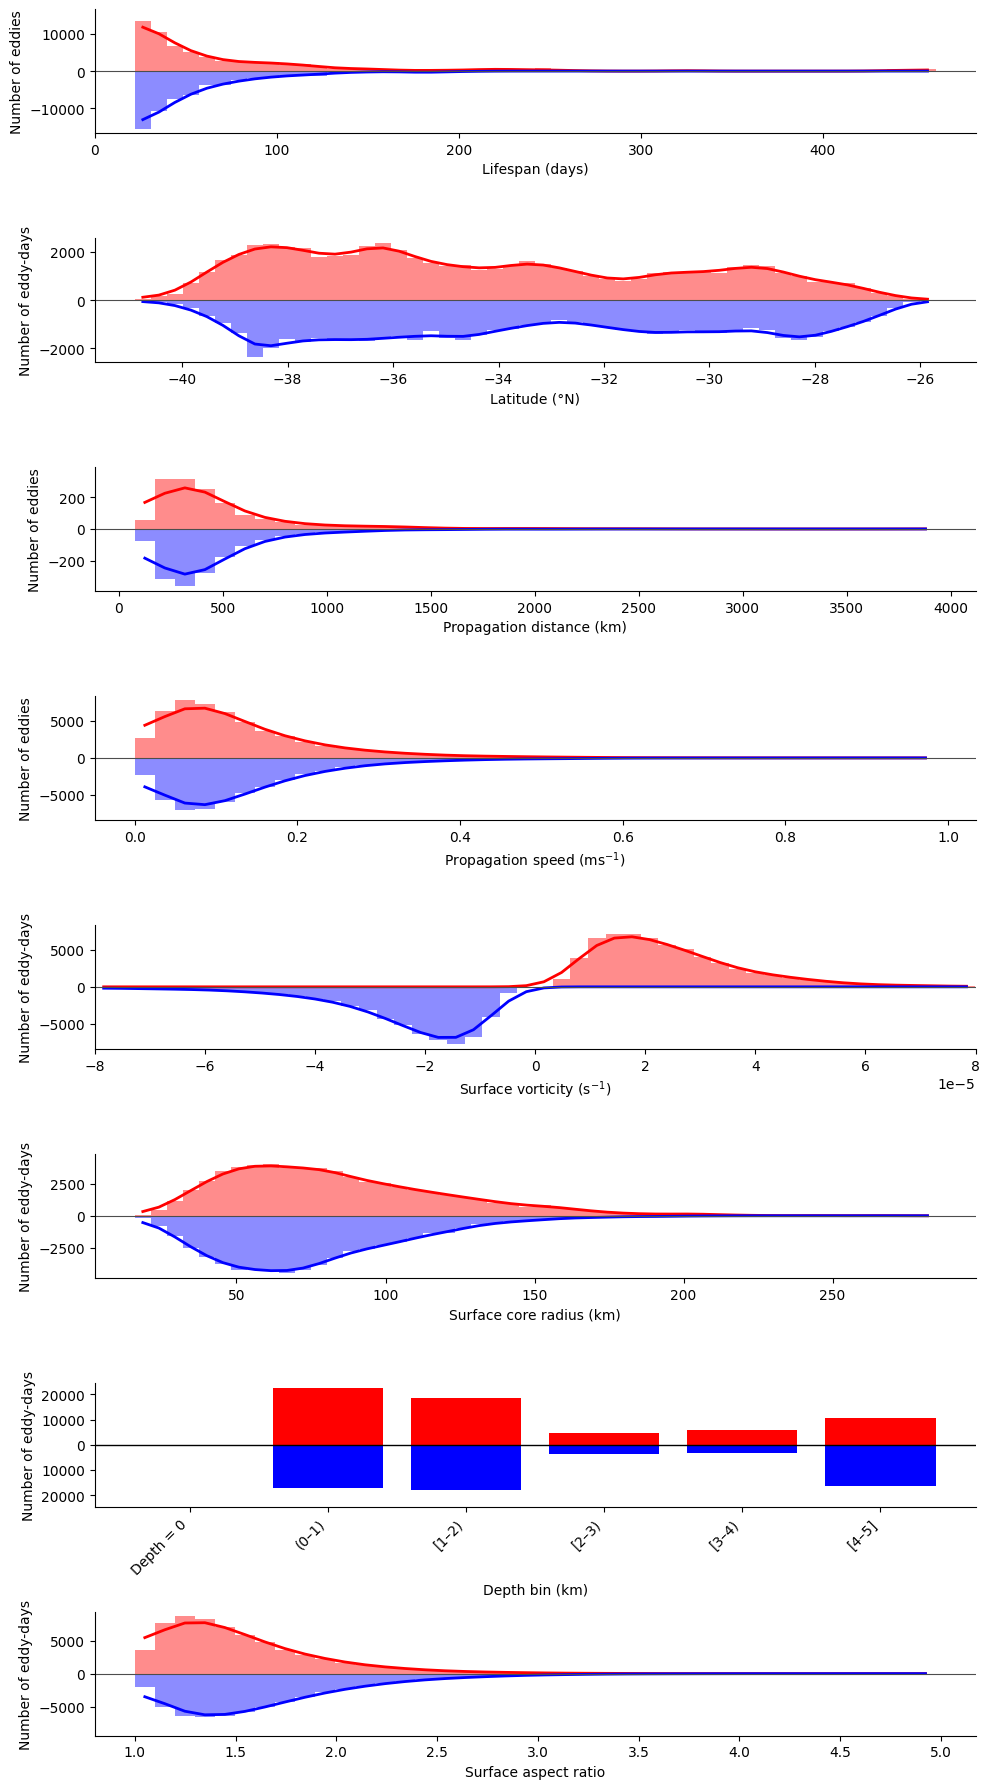

In [5]:
max_depth = (
    df_vert.groupby(["Eddy", "Day"], as_index=False)["Depth"]
    .max()
    .rename(columns={"Depth": "max_profile_depth"})
)
max_depth["max_profile_depth"] /= 1e3
df_eddies = df_eddies.merge(max_depth, on=["Eddy", "Day"], how="inner")
fig, axs = at.summary_plot(df_eddies.copy())

In [6]:
d = df_eddies.max_profile_depth.value_counts().sort_index()
print(pd.DataFrame({
    'n': d,
    'frac': d / d.sum(),
    'cum_frac': d.cumsum() / d.sum()
}))

                       n      frac  cum_frac
max_profile_depth                           
0.010726            1016  0.008429  0.008429
0.016383             600  0.004977  0.013406
0.022926             439  0.003642  0.017048
0.030444             385  0.003194  0.020242
0.039053             403  0.003343  0.023585
0.048898             440  0.003650  0.027235
0.060171             434  0.003600  0.030835
0.073128             657  0.005450  0.036286
0.088117             723  0.005998  0.042284
0.105616             882  0.007317  0.049601
0.126288            1102  0.009142  0.058743
0.151066            1332  0.011050  0.069793
0.181265            1559  0.012933  0.082726
0.218755            2052  0.017023  0.099749
0.266206            2664  0.022100  0.121849
0.327441            3390  0.028123  0.149971
0.407922            3839  0.031848  0.181819
0.515416            4700  0.038990  0.220809
0.660806            5727  0.047510  0.268319
0.858918            7453  0.061829  0.330148
1.128898  

Text(0, 0.5, 'Count')

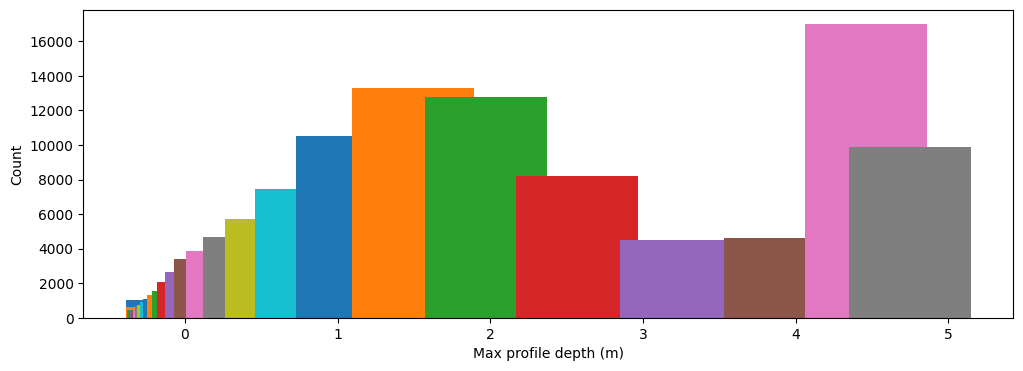

In [7]:
plt.figure(figsize=(12,4))
d = df_eddies.max_profile_depth.value_counts().sort_index()
plt.bar(d.index, d.values, color=plt.cm.tab10(np.arange(len(d)) % 10))
plt.xlabel('Max profile depth (m)')
plt.ylabel('Count')

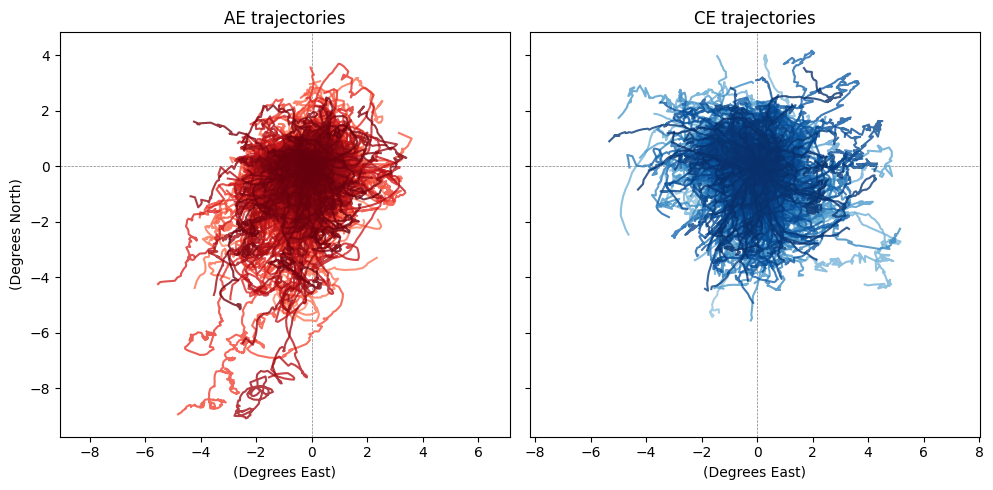

In [8]:
fig, axs = at.eddy_trajectories(df_eddies.copy())

In [9]:
dt = df_eddies.groupby('Eddy')['Day'].diff()
df_eddies['prop_x'] = df_eddies.groupby('Eddy')['xc'].diff() / dt
df_eddies['prop_y'] = df_eddies.groupby('Eddy')['yc'].diff() / dt
df_eddies['prop_dis'] = np.hypot(
    df_eddies['prop_x'],
    df_eddies['prop_y']
)
# Bearing: 0° = North, 90° = East
df_eddies['prop_dir'] = (
    np.degrees(
        np.arctan2(
            df_eddies['prop_x'],
            df_eddies['prop_y']
        )
    ) + 20
) % 360

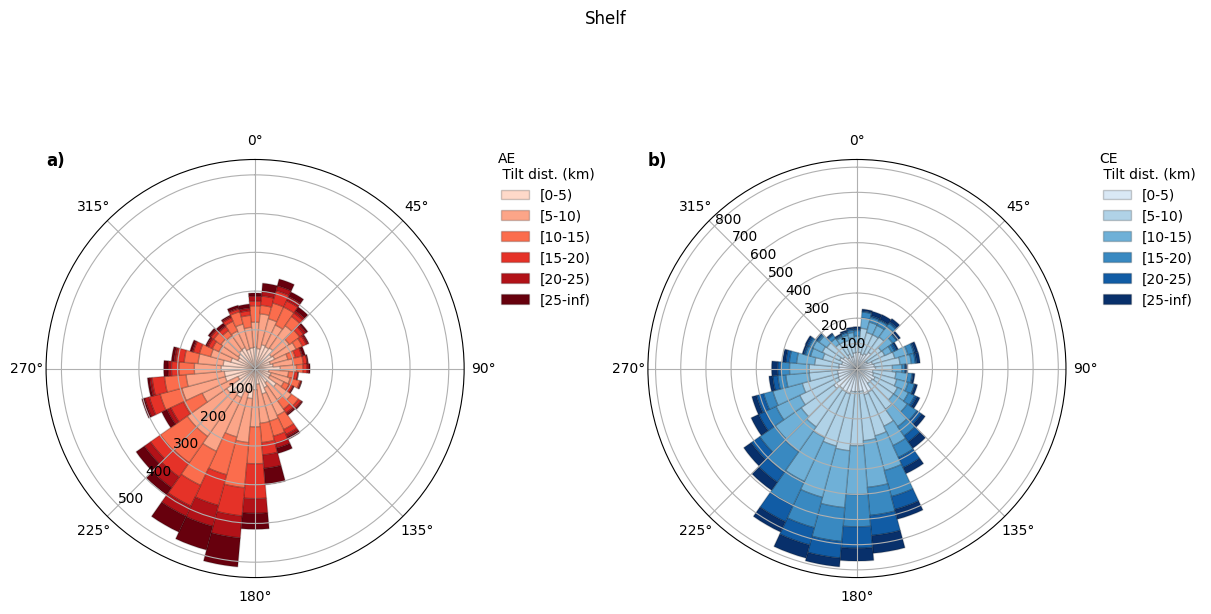

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
# mag_bins = [0, 10, 20, 30, np.inf]
mag_bins = [0, 5, 10, 15, 20, 25, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["prop_dir", "prop_dis"])
    subset = subset[subset.Region.isin(['S1', 'S2'])]
    tilt.plot_windrose(ax, subset, title='', colors=colors, mag='prop_dis', theta='prop_dir', mag_bins=mag_bins)#, rlim=2300)# 
    ax.legend(title=f"{cyc}\n Tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)

    ax.text(-0.0, 1.02, 'a)' if cyc=='AE' else 'b)', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
plt.suptitle('Shelf')
plt.show()

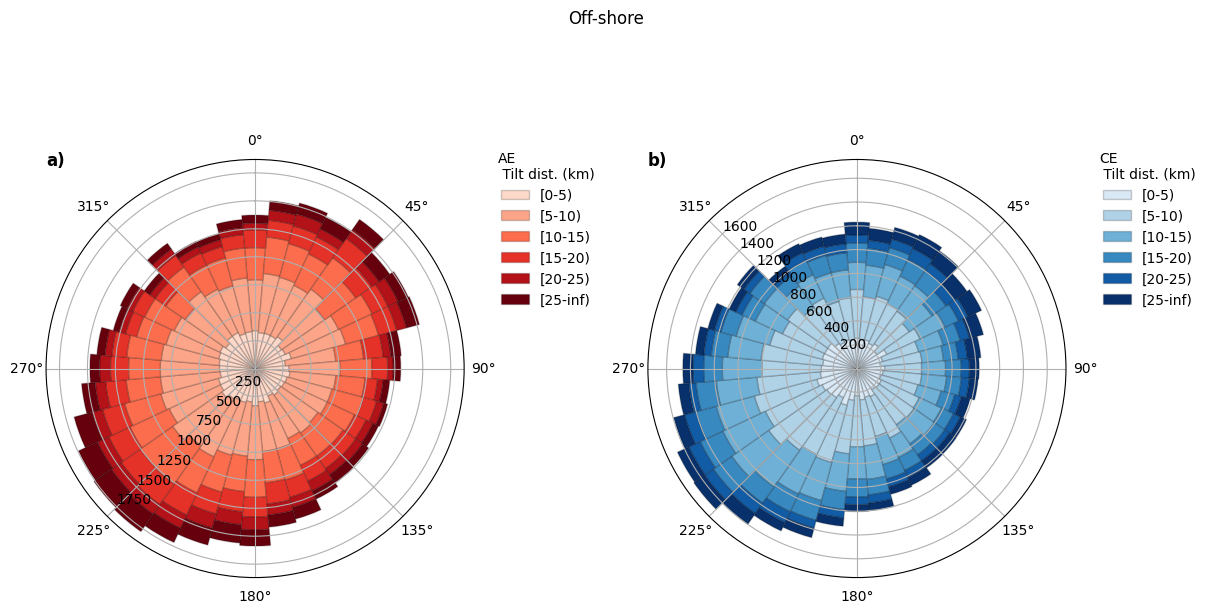

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = [0, 5, 10, 15, 20, 25, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["prop_dir", "prop_dis"])
    subset = subset[subset.Region.isin(['U1','U2','D1','D2'])]
    tilt.plot_windrose(ax, subset, title='', colors=colors, mag='prop_dis', theta='prop_dir', mag_bins=mag_bins)#, rlim=2300)# 
    ax.legend(title=f"{cyc}\n Tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)

    ax.text(-0.0, 1.02, 'a)' if cyc=='AE' else 'b)', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
plt.suptitle('Off-shore')
plt.show()

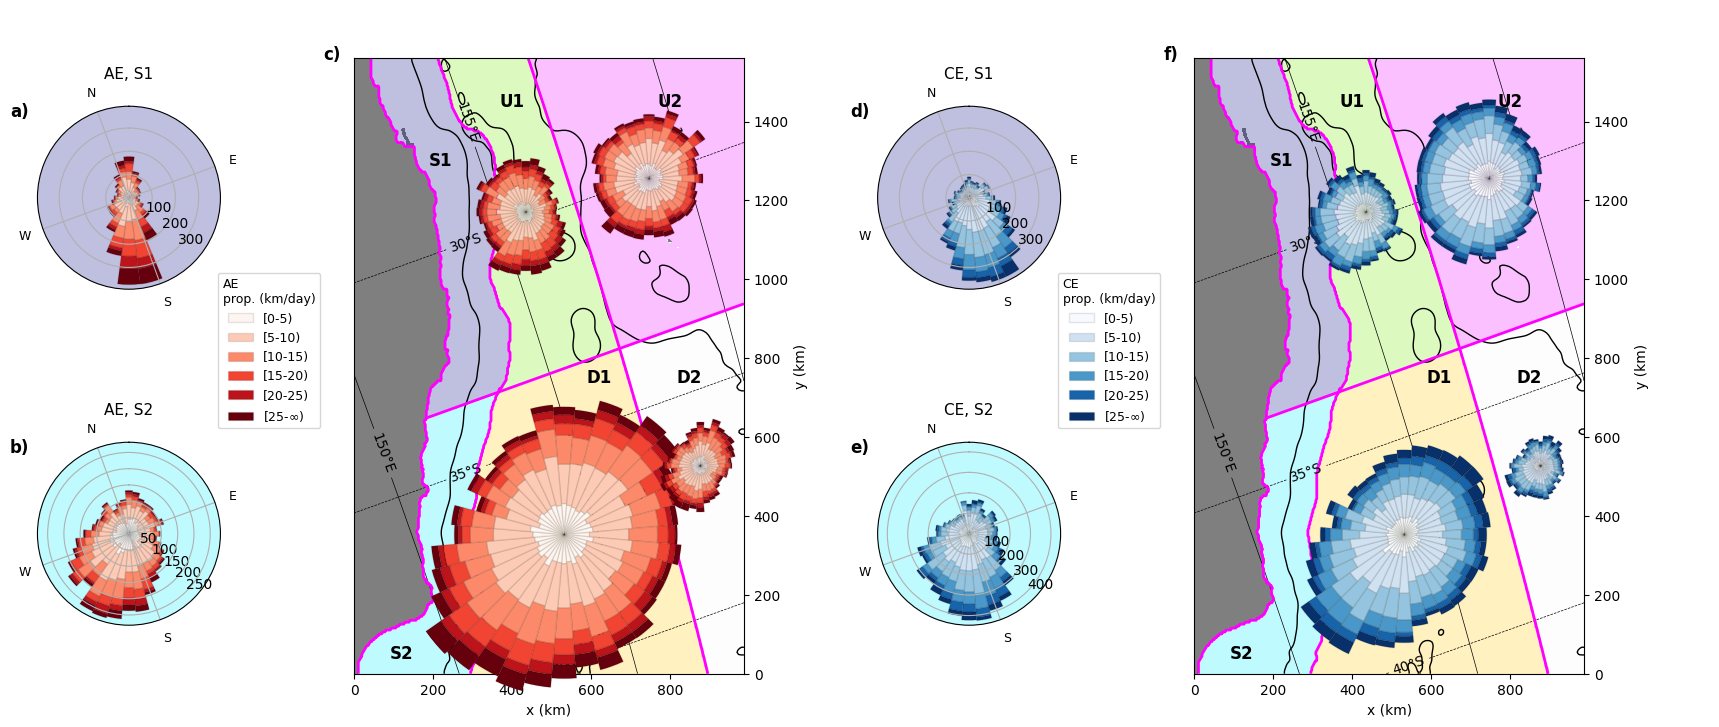

In [12]:
fig, rose = tilt.rose_plot(
    df_eddies.copy(),
    grid,
    mag="prop_dis",
    theta="prop_dir",
    frac=2.6,
    mag_bins=[0, 5, 10, 15, 20, 25, np.inf],
    legend_title="prop. (km/day)",
    cmaps = ['Reds', 'Blues']
)

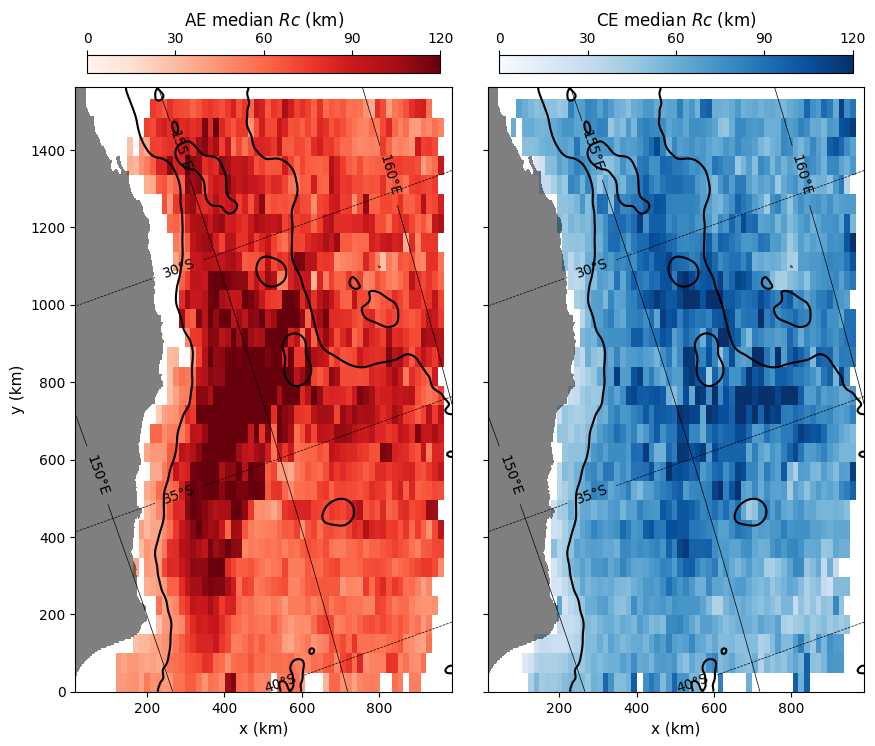

In [13]:
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric='Rc', vmin=0, vmax=120)

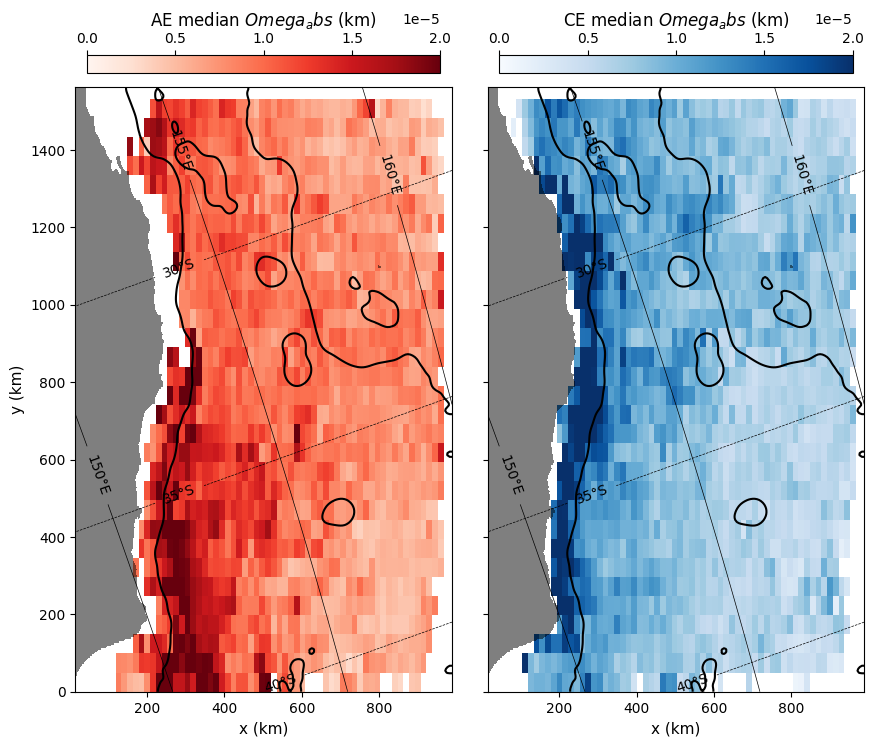

In [14]:
df = df_eddies.copy()
df['Omega_abs'] = df_eddies.Omega.abs()
fig, axs = tilt.plot_binned_median_map(df, grid, 
                                       metric='Omega_abs', vmin=0, vmax=2e-5)

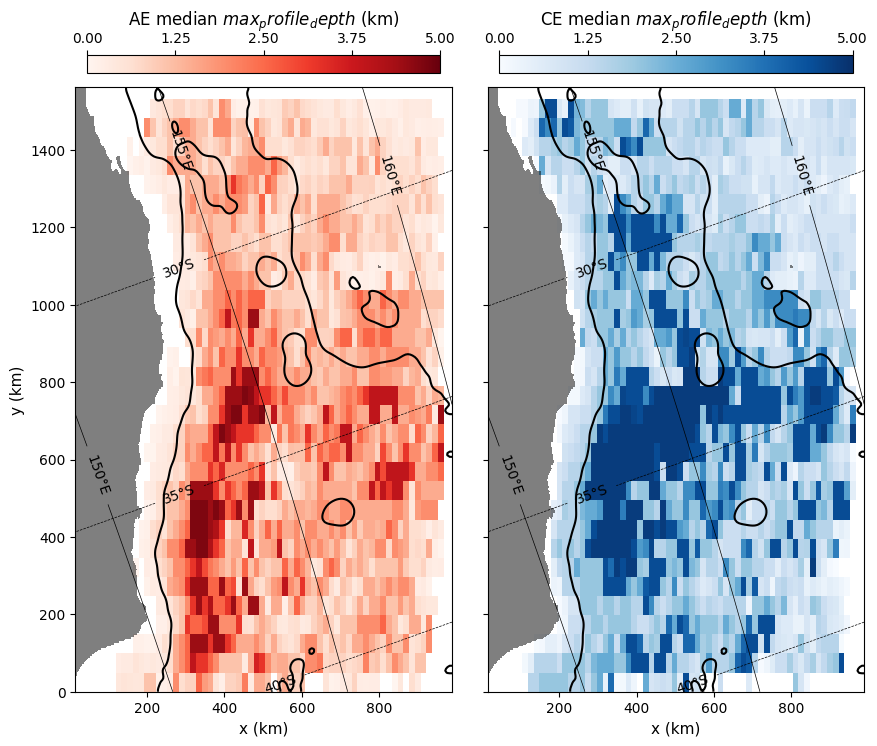

In [15]:
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric='max_profile_depth', vmin=0, vmax=5)

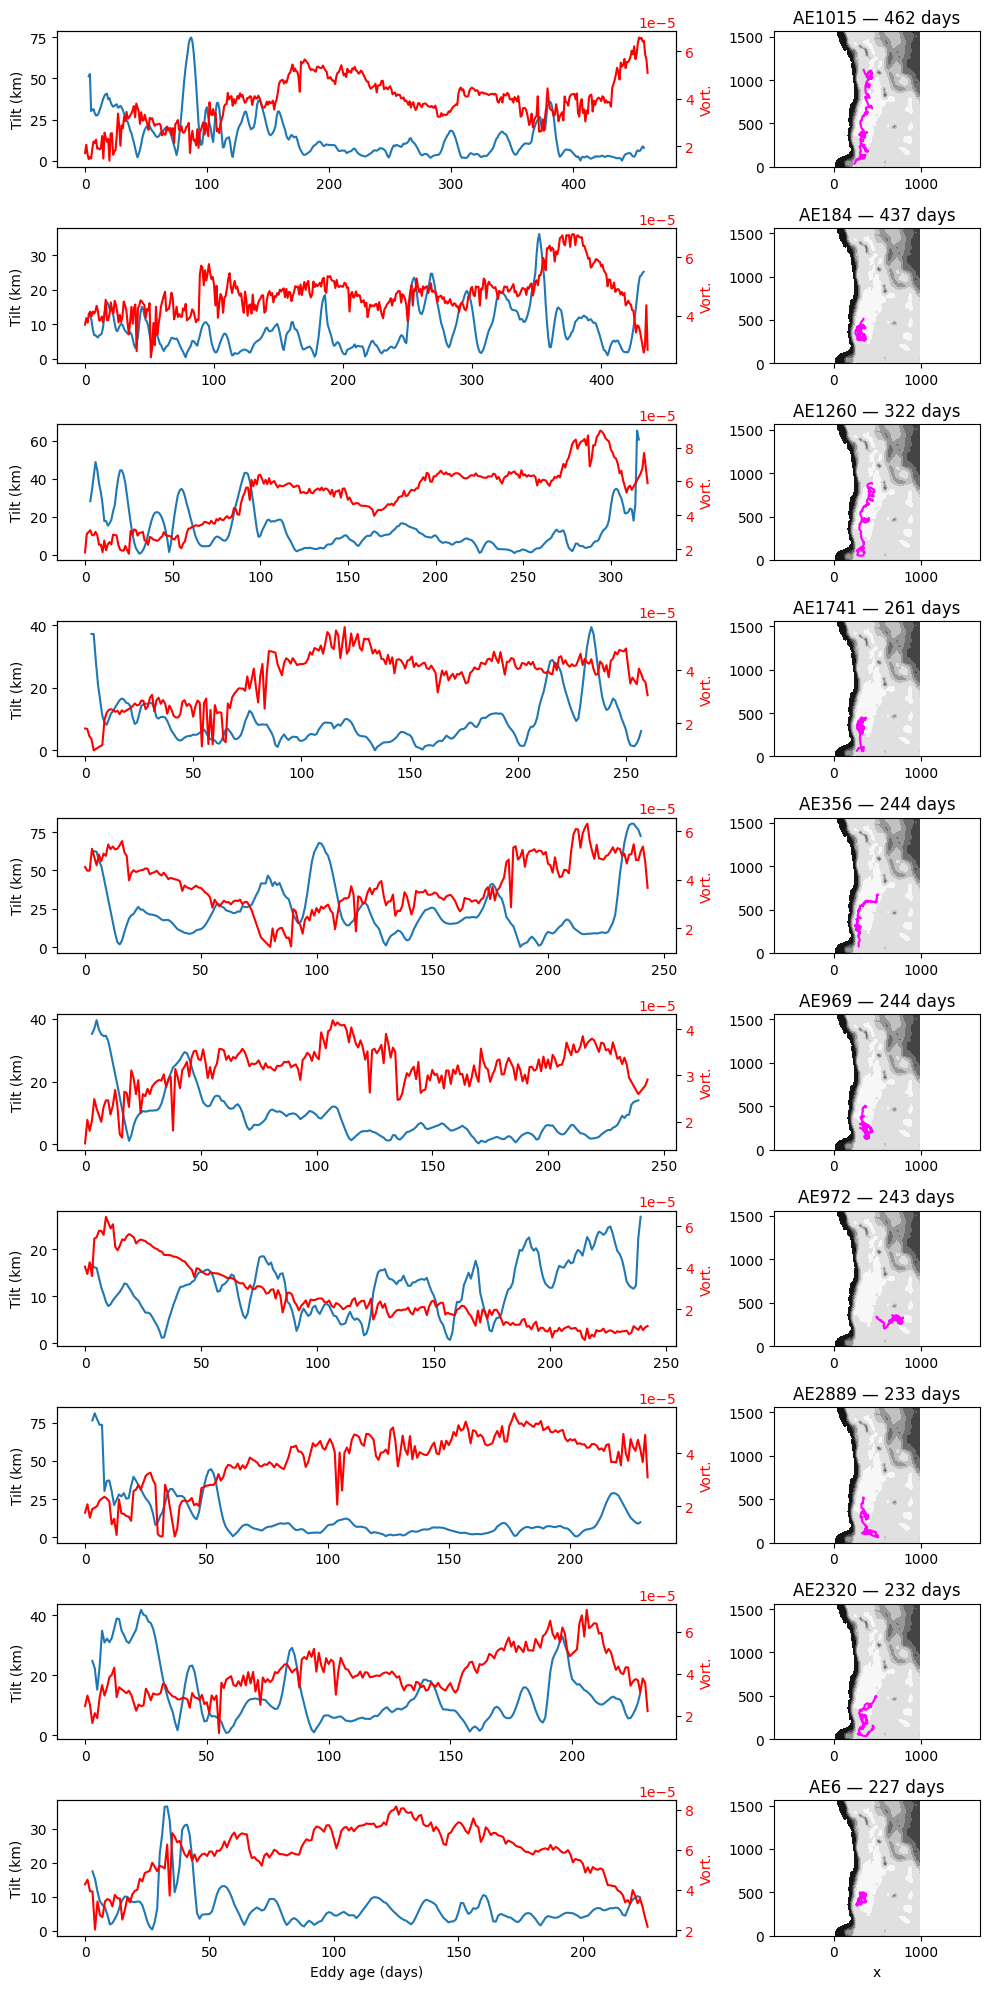

In [16]:
fig, axs = tilt.tilt_t(df_eddies.copy(), grid, add_field='w', field_label='Vort.')

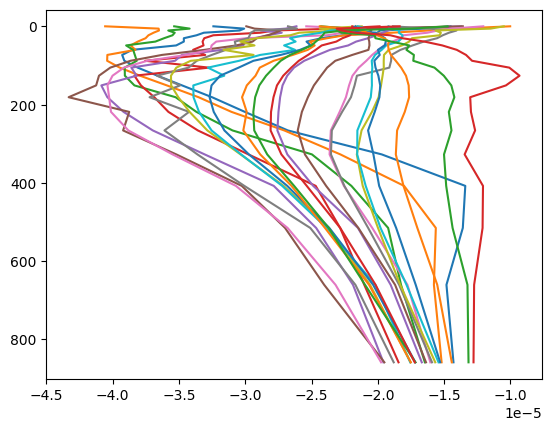

In [20]:
eddy = 1 
df = df_vert[df_vert.Eddy==eddy].copy()
df = df[df.Depth < 1e3]

fig, ax = plt.subplots()
for day in df.Day.unique():
    dff = df[df.Day==day].copy()
    ax.plot(dff.w, dff.Depth)
ax.invert_yaxis() 